In [28]:
import pandas as pd

# Load project dataset
file_path = "../datasets/raw/project_module_dataset2.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (800, 20)


In [29]:
print("Columns in the dataset:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns in the dataset:

1. total_tasks
2. avg_progress
3. avg_estimated_hours
4. total_estimated_hours
5. avg_hours_logged
6. total_hours_logged
7. hours_efficiency
8. project_duration_days
9. completed_task_count
10. in_progress_task_count
11. on_hold_task_count
12. not_started_task_count
13. cancelled_task_count
14. avg_allocation_score
15. avg_workload
16. avg_experience
17. avg_performance
18. avg_task_duration_days
19. risk_level
20. status


In [31]:
print("Project Status Distribution:")
print(df["status"].value_counts())




Project Status Distribution:
status
Completed      210
In Progress    196
Delayed        140
On Hold        127
Planning       127
Name: count, dtype: int64


In [35]:
# Create binary target
df["is_delayed"] = (df["status"] == "Delayed").astype(int)

print("Binary target distribution:")
print(df["is_delayed"].value_counts())

print("\nTarget percentages:")
print(df["is_delayed"].value_counts(normalize=True).mul(100).round(2))

Binary target distribution:
is_delayed
0    660
1    140
Name: count, dtype: int64

Target percentages:
is_delayed
0    82.5
1    17.5
Name: proportion, dtype: float64


In [36]:
feature_columns = [
    "total_tasks",
    "avg_progress",
    "avg_estimated_hours",
    "total_estimated_hours",
    "avg_hours_logged",
    "total_hours_logged",
    "hours_efficiency",
    "project_duration_days",
    "completed_task_count",
    "in_progress_task_count",
    "on_hold_task_count",
    "not_started_task_count",
    "cancelled_task_count",
    "avg_allocation_score",
    "avg_workload",
    "avg_experience",
    "avg_performance",
    "avg_task_duration_days",
    "risk_level"
]

X = df[feature_columns].copy()
y = df["is_delayed"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny distribution:")
print(y.value_counts())

X shape: (800, 19)
y shape: (800,)

X columns:
['total_tasks', 'avg_progress', 'avg_estimated_hours', 'total_estimated_hours', 'avg_hours_logged', 'total_hours_logged', 'hours_efficiency', 'project_duration_days', 'completed_task_count', 'in_progress_task_count', 'on_hold_task_count', 'not_started_task_count', 'cancelled_task_count', 'avg_allocation_score', 'avg_workload', 'avg_experience', 'avg_performance', 'avg_task_duration_days', 'risk_level']

y distribution:
is_delayed
0    660
1    140
Name: count, dtype: int64


In [37]:
X = pd.get_dummies(
    X,
    columns=["risk_level"],
    dtype=int
)

print("X shape after encoding:", X.shape)
print("\nX columns:")
print(X.columns.tolist())

X shape after encoding: (800, 22)

X columns:
['total_tasks', 'avg_progress', 'avg_estimated_hours', 'total_estimated_hours', 'avg_hours_logged', 'total_hours_logged', 'hours_efficiency', 'project_duration_days', 'completed_task_count', 'in_progress_task_count', 'on_hold_task_count', 'not_started_task_count', 'cancelled_task_count', 'avg_allocation_score', 'avg_workload', 'avg_experience', 'avg_performance', 'avg_task_duration_days', 'risk_level_Critical', 'risk_level_High', 'risk_level_Low', 'risk_level_Medium']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set:
X_train: (640, 22)
y_train: (640,)

Testing set:
X_test: (160, 22)
y_test: (160,)

Training target distribution:
is_delayed
0    528
1    112
Name: count, dtype: int64

Testing target distribution:
is_delayed
0    132
1     28
Name: count, dtype: int64


In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [40]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))
print("\nPredicted class distribution:")
print(pd.Series(y_pred).value_counts())

Predictions completed!
Number of predictions: 160

Predicted class distribution:
0    133
1     27
Name: count, dtype: int64


In [41]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Delayed", "Delayed"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.99375

Classification Report:
              precision    recall  f1-score   support

 Not Delayed       0.99      1.00      1.00       132
     Delayed       1.00      0.96      0.98        28

    accuracy                           0.99       160
   macro avg       1.00      0.98      0.99       160
weighted avg       0.99      0.99      0.99       160


Confusion Matrix:
[[132   0]
 [  1  27]]


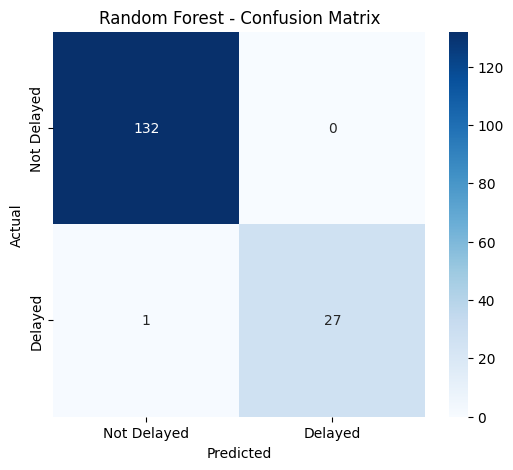

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Delayed", "Delayed"],
    yticklabels=["Not Delayed", "Delayed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed successfully!")

XGBoost training completed successfully!


In [44]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions completed!")
print("Number of predictions:", len(y_pred_xgb))

print("\nPredicted class distribution:")
print(pd.Series(y_pred_xgb).value_counts())

XGBoost predictions completed!
Number of predictions: 160

Predicted class distribution:
0    134
1     26
Name: count, dtype: int64


In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Not Delayed", "Delayed"]
    )
)

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9875

XGBoost Classification Report:
              precision    recall  f1-score   support

 Not Delayed       0.99      1.00      0.99       132
     Delayed       1.00      0.93      0.96        28

    accuracy                           0.99       160
   macro avg       0.99      0.96      0.98       160
weighted avg       0.99      0.99      0.99       160


XGBoost Confusion Matrix:
[[132   0]
 [  2  26]]


In [46]:
import joblib
import os

# Create model directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained Random Forest model
joblib.dump(model, "../models/project_delay_random_forest.pkl")

# Save the feature column order
joblib.dump(X.columns.tolist(), "../models/project_delay_features.pkl")

print("Random Forest model saved successfully!")
print("Model: ../models/project_delay_random_forest.pkl")
print("Features: ../models/project_delay_features.pkl")

Random Forest model saved successfully!
Model: ../models/project_delay_random_forest.pkl
Features: ../models/project_delay_features.pkl


In [47]:
import joblib

delay_model = joblib.load(
    "../models/project_delay_random_forest.pkl"
)

delay_features = joblib.load(
    "../models/project_delay_features.pkl"
)

print("Delay model loaded successfully!")
print("Number of features:", len(delay_features))
print("\nFeatures:")
print(delay_features)

Delay model loaded successfully!
Number of features: 22

Features:
['total_tasks', 'avg_progress', 'avg_estimated_hours', 'total_estimated_hours', 'avg_hours_logged', 'total_hours_logged', 'hours_efficiency', 'project_duration_days', 'completed_task_count', 'in_progress_task_count', 'on_hold_task_count', 'not_started_task_count', 'cancelled_task_count', 'avg_allocation_score', 'avg_workload', 'avg_experience', 'avg_performance', 'avg_task_duration_days', 'risk_level_Critical', 'risk_level_High', 'risk_level_Low', 'risk_level_Medium']


In [48]:
import pandas as pd

def predict_project_delay(project_data):
    
    # Convert input data into a DataFrame
    input_df = pd.DataFrame([project_data])
    
    # Encode risk_level exactly like during training
    input_df = pd.get_dummies(
        input_df,
        columns=["risk_level"],
        dtype=int
    )
    
    # Add any missing risk-level columns
    risk_columns = [
        "risk_level_Critical",
        "risk_level_High",
        "risk_level_Low",
        "risk_level_Medium"
    ]
    
    for col in risk_columns:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Keep exactly the features used during training
    input_df = input_df[delay_features]
    
    # Make prediction
    prediction = delay_model.predict(input_df)[0]
    
    # Convert 0/1 into readable result
    if prediction == 1:
        return "Delayed"
    else:
        return "Not Delayed"

print("Prediction function created successfully!")

Prediction function created successfully!


In [49]:
# Take the first project from the dataset
test_project = df.iloc[0][feature_columns].to_dict()

# Predict delay
prediction = predict_project_delay(test_project)

print("Predicted Project Status:", prediction)
print("Actual Project Status:", df.iloc[0]["status"])

Predicted Project Status: Delayed
Actual Project Status: Delayed


In [50]:
# Find one delayed project and one non-delayed project
delayed_project = df[df["is_delayed"] == 1].iloc[0][feature_columns].to_dict()
not_delayed_project = df[df["is_delayed"] == 0].iloc[0][feature_columns].to_dict()

# Predictions
delayed_prediction = predict_project_delay(delayed_project)
not_delayed_prediction = predict_project_delay(not_delayed_project)

print("Delayed project:")
print("Predicted:", delayed_prediction)
print("Actual: Delayed")

print("\nNot Delayed project:")
print("Predicted:", not_delayed_prediction)
print("Actual:", "Not Delayed")

Delayed project:
Predicted: Delayed
Actual: Delayed

Not Delayed project:
Predicted: Not Delayed
Actual: Not Delayed
